# 4.0 Model training - LightGBM


## Imports


In [1]:
import numpy as np
import pandas as pd
import joblib
import json
import shap
import matplotlib.pyplot as plt
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_log_error

from recruit_restaurant_visitor_forecasting.config import (
    AIR_RESTAURANT_ID_COL,
    MODELS_DIR,
    VISIT_DATE_COL,
    DAY_OF_WEEK_COL,
    VISITORS_NBR_COL,
    CITY_COL,
)
from recruit_restaurant_visitor_forecasting.dataset import read_csv, DataDir, save_csv
from recruit_restaurant_visitor_forecasting.modeling.train import (
    build_feature_drop_list,
    load_data,
    prepare_features,
    light_gbm_gridsearch,
    permutation_importance_fs,
    shap_fs,
    train_test_split_by_date,
)
from recruit_restaurant_visitor_forecasting.plots import plot_daily_pred, plot_feature_importances
from recruit_restaurant_visitor_forecasting.utils import merge_daily_pred, convert_to_serializable, get_format
from recruit_restaurant_visitor_forecasting.modeling.predict import recursive_predict

2026-01-07 13:51:40.368 | INFO     | recruit_restaurant_visitor_forecasting.config:<module>:12 - PROJ_ROOT path is: D:\mentoring_program


In [10]:
CV_SPLITS = 3
TEST_SIZE = 0.2
DROP_COLUMNS = [AIR_RESTAURANT_ID_COL, VISIT_DATE_COL, VISITORS_NBR_COL, DAY_OF_WEEK_COL, CITY_COL]

FS_TOP_K = 35
PERM_N_REPEATS = 5
FS_VALID_SIZE = 0.2

MODEL_PATH = MODELS_DIR / "lightgbm_model.pkl"

## Load and prepare

In [3]:
features, labels = load_data()
print(f"Features shape: {features.shape}")
print(f"Labels shape: {labels.shape}")

Features shape: (271221, 50)
Labels shape: (271221,)


In [4]:
original_index = features.index.copy()
features = prepare_features(features)

labels = labels.loc[features.index].reset_index(drop=True)
features = features.reset_index(drop=True)

In [5]:
X = features
y = labels

In [6]:
X_train, X_test, y_train, y_test = train_test_split_by_date(
    X, y, date_col=VISIT_DATE_COL, test_size=TEST_SIZE
)

train_dates = X_train[VISIT_DATE_COL]
test_dates = X_test[VISIT_DATE_COL]

print(f"Train set dates: {train_dates.min()} to {train_dates.max()}")
print(f"Test set dates: {test_dates.min()} to {test_dates.max()}")

Train set dates: 2016-02-01 00:00:00 to 2017-01-22 00:00:00
Test set dates: 2017-01-23 00:00:00 to 2017-04-22 00:00:00


## Feature selection

In [11]:
lgbm = LGBMRegressor(random_state=42, n_estimators=150)
selected_features, feature_stats = shap_fs(
    X_train,
    y_train,
    lgbm,
    drop_features=DROP_COLUMNS,
    test_size=FS_VALID_SIZE,
    top_k=FS_TOP_K,
)

FEATURES_TO_DROP = build_feature_drop_list(
    X.columns.tolist(),
    selected_features,
)
FEATURES_TO_KEEP = [c for c in X.columns if c not in FEATURES_TO_DROP]

print("Selected features: ", selected_features)
feature_stats.head()

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.017310 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8931
[LightGBM] [Info] Number of data points in the train set: 138296, number of used features: 45
[LightGBM] [Info] Start training from score 17.665797
Selected features:  ['visitors_dow_mean', 'total_reserves', 'res_visitors_diff_mean_14', 'visitors_mean_7', 'res_visitors_diff_mean_7', 'visitors_lag_7', 'res_visitors_diff', 'total_reserves_nbrs', 'visitors_lag_28', 'open_usually', 'visitors_nbrs_lag_1', 'days_from_holiday', 'visitors_mean_14', 'visitors_lag_1', 'visitors_dow_mean_nbrs', 'opened_recently', 'visitors_mean_28', 'visitors_median_7', 'nbr_res_visitors_diff_mean_14', 'nbr_res_visitors_diff_mean_7', 'visitors_median_14', 'res_visitors_diff_mean_28', 'nbr_res_visitors_diff', 'visitors_median_28', 'visitors_nbrs_median_14', 'visitors_last_month', 'holiday_flg', 'nbr_res_visitors_diff_mean

,feature,shap_mean_abs,shap_std_abs
0,visitors_dow_mean,6.574063,4.962086
1,total_reserves,1.235041,3.555439
2,res_visitors_diff_mean_14,0.955726,0.678592
3,visitors_mean_7,0.874105,0.964664
4,res_visitors_diff_mean_7,0.603274,0.427692


## Training


In [12]:
grid_search = light_gbm_gridsearch(
    verbose=3,
    n_jobs=-1,
    drop_features=FEATURES_TO_DROP,
    n_splits=CV_SPLITS,
)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)

Fitting 3 folds for each of 1458 candidates, totalling 4374 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.017025 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7032
[LightGBM] [Info] Number of data points in the train set: 197104, number of used features: 35
[LightGBM] [Info] Start training from score 17.605584
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

In [13]:
pd.DataFrame(grid_search.cv_results_).sort_values("rank_test_score").head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__learning_rate,param_model__max_depth,param_model__min_child_samples,param_model__n_estimators,param_model__num_leaves,param_model__reg_alpha,param_model__reg_lambda,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
431,7.486756,0.651637,0.007106,0.001623,0.1,5,20,200,31,1.0,1.0,"{'model__learning_rate': 0.1, 'model__max_dept...",-0.615535,-0.610765,-0.773643,-0.666648,0.075682,1
369,11.006449,0.637996,0.009426,0.000869,0.1,5,10,200,31,0.0,0.0,"{'model__learning_rate': 0.1, 'model__max_dept...",-0.614596,-0.612797,-0.776645,-0.668013,0.076818,2
481,6.729298,0.437611,0.005868,0.000345,0.1,5,30,200,31,0.1,0.1,"{'model__learning_rate': 0.1, 'model__max_dept...",-0.617207,-0.612237,-0.775004,-0.668149,0.075585,3
478,6.423905,0.092754,0.005835,0.000132,0.1,5,30,200,31,0.0,0.1,"{'model__learning_rate': 0.1, 'model__max_dept...",-0.611988,-0.608350,-0.784165,-0.668167,0.082036,4
477,6.914364,0.403771,0.006194,0.000223,0.1,5,30,200,31,0.0,0.0,"{'model__learning_rate': 0.1, 'model__max_dept...",-0.615886,-0.612188,-0.777335,-0.668470,0.076994,5


In [14]:
model = grid_search.best_estimator_
y_train_pred = model.predict(X_train)
y_train_pred = np.maximum(y_train_pred, 0)

train_rmsle = np.sqrt(mean_squared_log_error(y_train, y_train_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

print(f"Train set metrics:")
print(f"RMSLE: {train_rmsle:.4f}")
print(f"MAE:  {train_mae:.4f}")
print(f"R2:   {train_r2:.4f}")

Train set metrics:
RMSLE: 0.8341
MAE:  6.5654
R2:   0.6475


In [21]:
y_test_pred, temp_features = recursive_predict(
    model,
    X_test,
    X_train,
    y_train,
    drop_cols=FEATURES_TO_DROP,
)

Predicting recursively:   0%|          | 0/90 [00:00<?, ?it/s]D:\mentoring_program\recruit_restaurant_visitor_forecasting\modeling\predict.py:148: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[1.83158722e+01 1.25756508e+01 8.42635476e+00 5.40041336e+00
 4.94585946e+00 1.93144036e+01 1.25470726e+01 3.98503515e+01
 3.11334787e+01 7.37487004e+00 3.09322418e+01 3.73363014e+00
 1.89898054e+01 2.97310354e+01 1.36995297e+01 9.21833530e+00
 9.23122011e-01 7.01474589e+00 2.79090584e+00 2.75377778e+01
 2.10858070e+01 4.02799528e+01 5.94512644e+00 1.10092221e+01
 9.54377539e+00 1.56081361e+01 4.05330800e+00 1.06605768e+01
 8.14280354e+00 2.49625910e+01 0.00000000e+00 4.44818426e+01
 2.51827094e+01 6.01181554e+00 5.66147148e-01 2.85799312e+01
 8.59081716e+00 3.79399896e+00 1.13551562e+01 9.65084848e+00
 1.35527558e+00 7.31627430e+00 1.43728120e+01 5.56155026e+00
 1.97605997e-01 1.89762422e+01 9.32283377e+00 3.93620

In [22]:
test_rmsle = np.sqrt(mean_squared_log_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)
print(f"\nTest set metrics:")
print(f"RMSLE: {test_rmsle:.4f}")
print(f"MAE:  {test_mae:.4f}")
print(f"R2:   {test_r2:.4f}")


Test set metrics:
RMSLE: 0.8353
MAE:  7.1042
R2:   0.5571


## Graphs

### Feature importances

<Figure size 1200x1000 with 0 Axes>

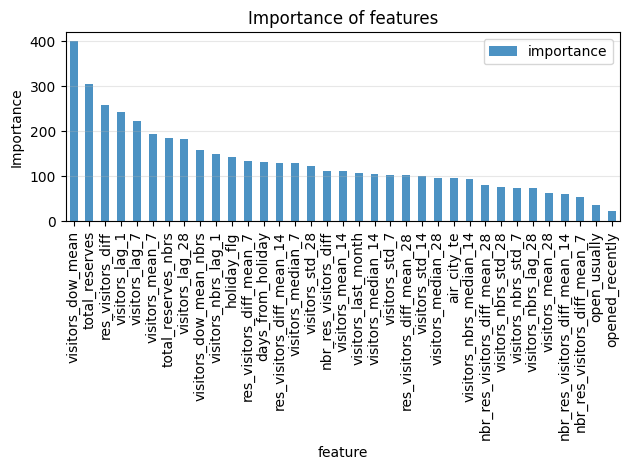

In [17]:
plot_feature_importances(model, FEATURES_TO_KEEP)

## SHAP explanation

In [18]:
X_test_clean = model.named_steps["feature_dropper"].transform(X_test)
lgbm = model.named_steps["model"]

explainer = shap.Explainer(lgbm)
shap_values = explainer(X_test_clean)

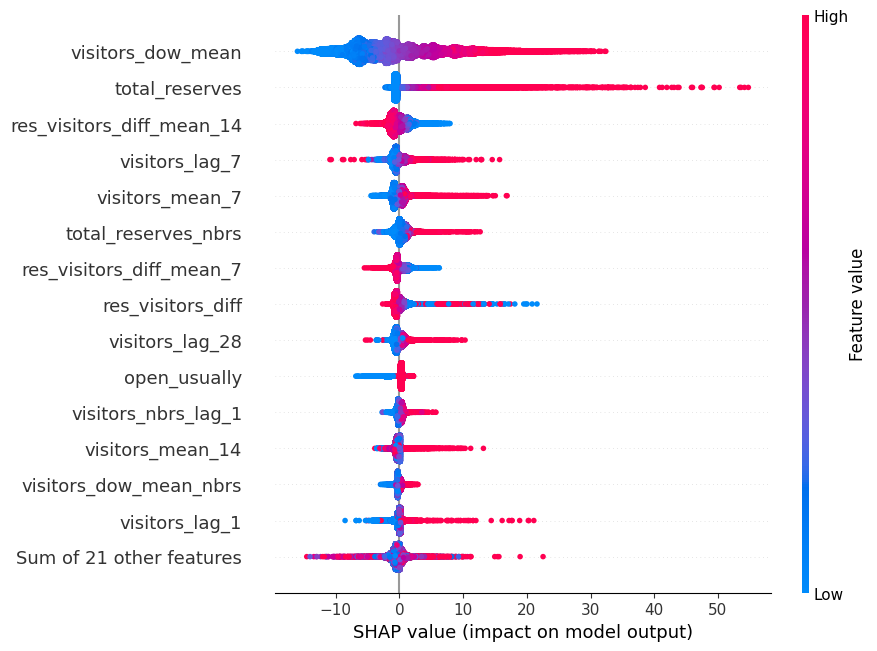

In [19]:
shap.plots.beeswarm(shap_values, max_display=15)

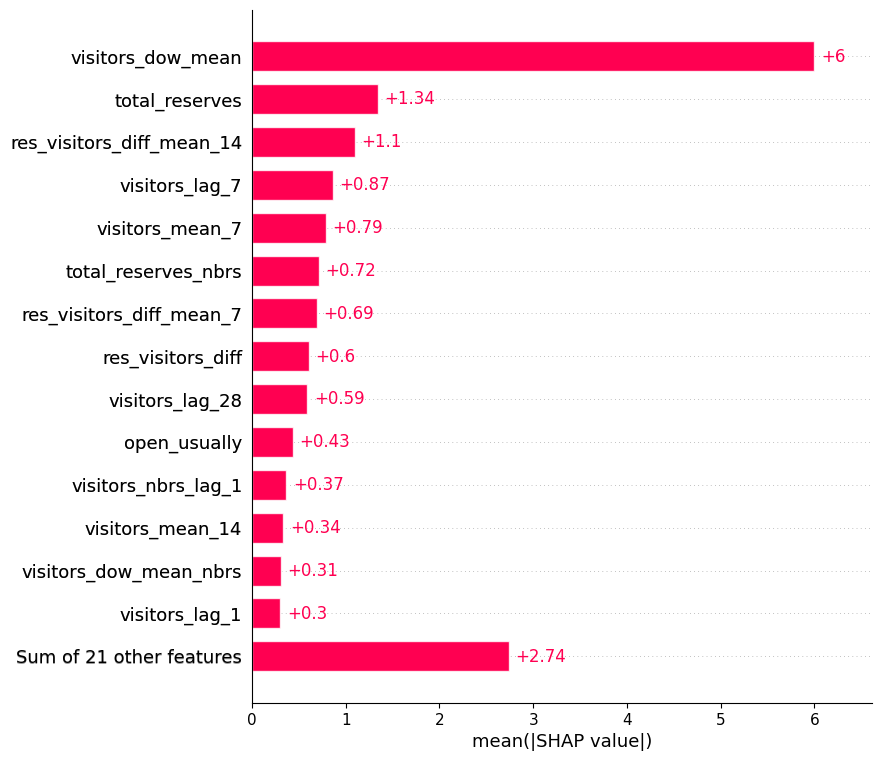

In [20]:
shap.plots.bar(shap_values, max_display=15)

### Visitors per day: actual vs predicted

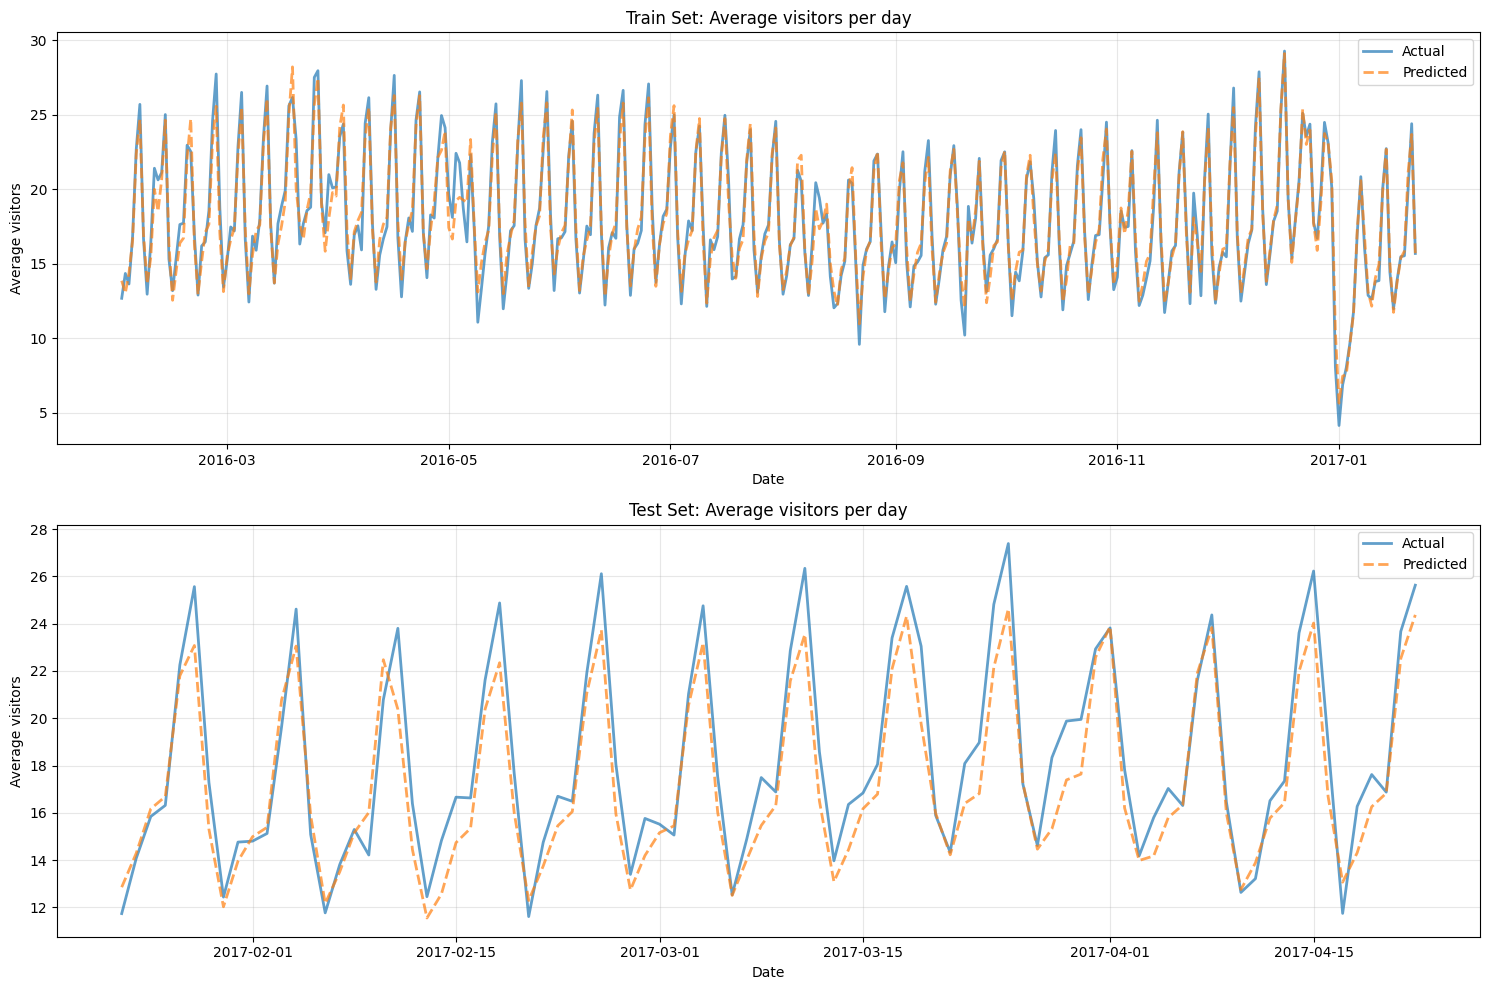

In [23]:
train_daily = merge_daily_pred(train_dates, y_train, y_train_pred)
test_daily = merge_daily_pred(test_dates, y_test, y_test_pred)

fig, axes = plt.subplots(2, 1, figsize=(15, 10))

plot_daily_pred(train_daily, axes[0], train=True)
plot_daily_pred(test_daily, axes[1], train=False)

plt.tight_layout()
plt.show()

## Testing on future data

In [7]:
model = joblib.load(MODEL_PATH)

In [17]:
test_features = read_csv("test_features.csv", DataDir.PROCESSED)
test_features = prepare_features(test_features)

In [ ]:
test_labels, temp_features = recursive_predict(
    model,
    test_features,
    X,
    y,
    drop_cols=FEATURES_TO_DROP,
)

Predicting recursively:   0%|          | 0/39 [00:00<?, ?it/s]D:\mentoring_program\recruit_restaurant_visitor_forecasting\modeling\predict.py:148: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[8.37109180e-01 3.37248204e-01 1.03479339e+01 4.61913489e+00
 2.57255563e+01 2.44264685e+01 2.66304582e+01 0.00000000e+00
 3.81849941e+01 1.75945609e+00 2.07324722e+01 4.66859705e+00
 2.73439303e+01 4.88731527e+01 2.38031978e+01 4.88283135e+00
 1.37481231e+01 1.15919158e+01 2.18970885e+01 5.16956968e+01
 5.73355060e+00 1.47841959e+01 1.43137226e+01 1.73611958e+01
 1.18424672e+00 3.00433979e+01 1.20250116e+01 2.23104833e+01
 7.80323992e-01 1.26528850e+01 2.12320051e+01 3.69215266e+00
 1.75362835e+01 9.64891485e+00 7.78135746e+00 0.00000000e+00
 1.27626680e+00 3.37576768e+01 2.05661007e+01 1.26103780e+01
 3.62562838e+01 3.65576604e+01 5.32703168e+00 7.86164364e-01
 1.58474846e+01 1.54115822e+01 1.91655124e+00 1.17306

In [19]:
labels_format = get_format(test_features, test_labels)
save_csv(labels_format, "test_labels.csv", DataDir.PROCESSED)

## Saving model

In [24]:
joblib.dump(model, MODEL_PATH)

params_to_save = {
    "best_params": convert_to_serializable(grid_search.best_params_),
    "best_score": float(grid_search.best_score_),
}

params_path = MODELS_DIR / "lightgbm_model_params.json"
with open(params_path, 'w', encoding='utf-8') as f:
    json.dump(params_to_save, f, indent=2, ensure_ascii=False)